In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci, lo
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow
from detnqs.vstate import MCState
from detnqs.sampler import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import adamsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

In [7]:
mol = gto.M(
    atom="; ".join([f"H 0 0 {i * 2.00}" for i in range(10)]),
    basis="sto-3g",
    unit="Angstrom",
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Orthonormalized Atomic Orbitals (OAOs)
C = lo.orth.orth_ao(mol, 'lowdin')
h1e = C.T @ mf.get_hcore() @ C
eri = ao2mo.restore(8, ao2mo.kernel(mol, C), mol.nao_nr())
h1e[abs(h1e) < 1e-6] = eri[abs(eri) < 1e-6] = 0.0
mo_coeff = np.linalg.solve(C, mf.mo_coeff)

ref_mat = np.zeros((n_alpha + n_beta, 2 * norb))
ref_mat[:n_alpha, :norb] = mo_coeff[:, :n_alpha].T
ref_mat[n_alpha:, norb:] = mo_coeff[:, :n_beta].T

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

solver = fci.direct_spin0.FCI(mol)
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

model = Backflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,), ref_mat=jnp.array(ref_mat))

SCF energy : -3.954499940085
FCI energy : -4.746238761902
S^2  : 0.000000


In [8]:
sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=1024,
    alpha="adaptive",
    proposal="ham",
    blur=0.5,
    blur_kernel="ham",
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="random",
    key=jax.random.key(0),
)

optimizer = optax.chain(
    adamsr(shift=1e-2),
    optax.scale(-5e-2)
)

vmc = VMC.init(state, optimizer)

history = []
steps = 1000

for step in range(steps):
    stats = vmc.step()
    history.append(stats['energy'])

    if step % 10 == 0 or step == steps - 1:
        print(
            f"step={step:4d}  "
            f"energy={history[-1]: .8f}  "
            f"variance={stats['variance']: .8f}  "
            f"acc={stats['accept']:.3f}  "
            f"ess={stats['ess']: .1f}  "
            f"n_unique={stats['n_unique']: .0f}  "
            f"n_eval={stats['n_eval']: .0f}  "
            f"alpha={stats['alpha']: .3f}  "
        )

        time_items = sorted(
            (k[5:], float(stats[k])) for k in stats if k.startswith("time_")
        )
        if time_items:
            line = " | ".join(f"{name}= {val:.4f}" for name, val in time_items)
            print(f"         times: " + line)

step=   0  energy=-3.93692675  variance= 0.30223415  acc=0.786  ess= 516.7  n_unique= 989  n_eval= 23089  alpha= 1.000  
         times: backward= 0.6905 | forward= 0.4338 | graph= 0.0779 | optimizer= 4.4455 | reduce= 0.0043 | sample= 0.0074 | total= 5.6599
step=  10  energy=-4.31973221  variance= 0.13410874  acc=0.690  ess= 387.5  n_unique= 962  n_eval= 22790  alpha= 1.050  
         times: backward= 0.0671 | forward= 0.1973 | graph= 0.0313 | optimizer= 0.5021 | reduce= 0.0041 | sample= 0.0072 | total= 0.8096
step=  20  energy=-4.53525956  variance= 0.06545918  acc=0.600  ess= 282.1  n_unique= 966  n_eval= 22373  alpha= 1.100  
         times: backward= 0.0091 | forward= 0.1238 | graph= 0.0440 | optimizer= 0.3270 | reduce= 0.0041 | sample= 0.0084 | total= 0.5170
step=  30  energy=-4.66170849  variance= 0.03076121  acc=0.519  ess= 229.5  n_unique= 930  n_eval= 21029  alpha= 1.150  
         times: backward= 0.0095 | forward= 0.0491 | graph= 0.0484 | optimizer= 0.3282 | reduce= 0.0026 |

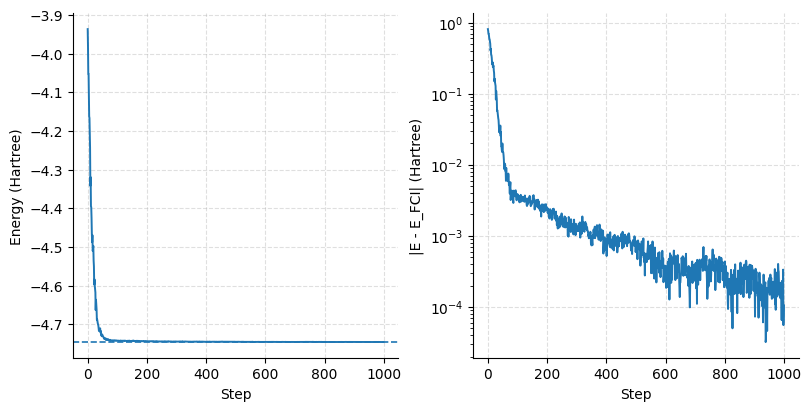

In [9]:
def plot_convergence(history, e_fci):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    step = np.arange(len(history))

    ax = axes[0]
    ax.plot(step, history, linewidth=1.4)
    ax.axhline(e_fci, linestyle="--", linewidth=1.2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Energy (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    ax.semilogy(step, np.abs(np.asarray(history) - e_fci), linewidth=1.4)
    ax.set_xlabel("Step")
    ax.set_ylabel("|E - E_FCI| (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    return fig, axes

plot_convergence(history, e_fci)
plt.show()